## Klasterovanje na skupu podataka `circles.csv`

**a)**  Primenom algoritma DBSCAN pronaći 2 klastera.

**b)** Primenom algoritma sakupljajućeg hijerarhijskog klasterovanja pronaći 2 klastera. Koristiti euklidsko rastojanje.

**c)** Uporediti rezultate klasterovanja u odnosu na tip veze (min, max, avg), kao i u odnosu na DBSCAN. Da li su rezultati očekivani? Zašto?

**d)** Prikazati grafički rezultate koristeći scatter plot. Obojiti instance na osnovu klastera kom pripadaju.

**e)** Da li je bilo potrebno podeliti podatke na trening i test skup? Da li je bilo potrebno dodatno pretprocesiranje podataka? Zašto?

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('circles.csv')
df.head()

,feature_0,feature_1
0,-0.075350,-0.214202
1,0.209757,0.138808
2,-0.151224,0.147409
3,0.764200,-0.593385
4,0.802416,-0.740742


In [3]:
df.describe()

,feature_0,feature_1
count,100.000000,100.000000
mean,0.002395,-0.001984
std,0.511907,0.516629
min,-1.077641,-1.082618
25%,-0.224070,-0.212846
50%,-0.021724,0.015592
75%,0.218280,0.216584
max,1.063061,1.035089


In [4]:
df.isna().any()

feature_0    False
feature_1    False
dtype: bool

Klasterovanje spada u nenadgledano učenje, pa nema potrebe da delimo na trening i test.

Normalizacija nije potrebna pošto su atributi na istoj skali.

In [5]:
from matplotlib import pyplot as plt

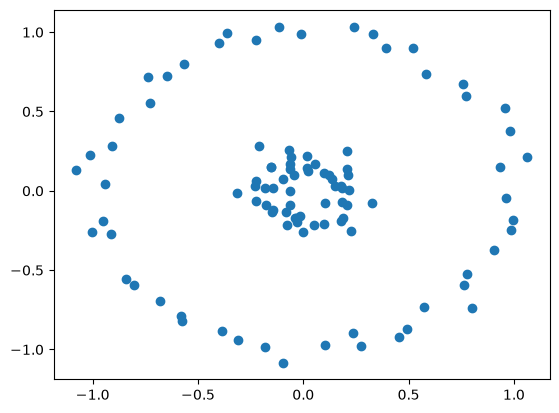

In [6]:
plt.scatter(df['feature_0'], df['feature_1'])

In [7]:
from sklearn.cluster import DBSCAN

In [8]:
model = DBSCAN(min_samples=5, eps=0.3)

In [9]:
model.fit(df)

,"eps eps: float, default=0.5The maximum distance between two samples for one to be consideredas in the neighborhood of the other. This is not a maximum boundon the distances of points within a cluster. This is the mostimportant DBSCAN parameter to choose appropriately for your data setand distance function. Smaller values generally lead to more clusters.",0.3
,"min_samples min_samples: int, default=5The number of samples (or total weight) in a neighborhood for a point tobe considered as a core point. This includes the point itself. If`min_samples` is set to a higher value, DBSCAN will find denser clusters,whereas if it is set to a lower value, the found clusters will be moresparse.",5
,"metric metric: str, or callable, default='euclidean'The metric to use when calculating distance between instances in afeature array. If metric is a string or callable, it must be one ofthe options allowed by :func:`sklearn.metrics.pairwise_distances` forits metric parameter.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors for DBSCAN... versionadded:: 0.17 metric *precomputed* to accept precomputed sparse matrix.",'euclidean'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function... versionadded:: 0.19",None
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'The algorithm to be used by the NearestNeighbors moduleto compute pointwise distances and find nearest neighbors.'auto' will attempt to decide the most appropriate algorithmbased on the values passed to :meth:`fit` method.See :class:`~sklearn.neighbors.NearestNeighbors` documentation fordetails.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or cKDTree. This can affect the speedof the construction and query, as well as the memory requiredto store the tree. The optimal value dependson the nature of the problem.",30
,"p p: float, default=NoneThe power of the Minkowski metric to be used to calculate distancebetween points. If None, then ``p=2`` (equivalent to the Euclideandistance). When p=1, this is equivalent to Manhattan distance.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
Name,Type,Value
"components_ components_: ndarray of shape (n_core_samples, n_features)Copy of each core sample found by training.","ndarray[float64](77, 2)","[[-0.08,-0.21], [ 0.21, 0.14], [-0.15, 0.15], ..., [-0.22, 0.95], [ 0.1 ,-0.21], [ 0.18, 0.03]]"
"core_sample_indices_ core_sample_indices_: ndarray of shape (n_core_samples,)Indices of core samples.","ndarray[int64](77,)","[ 0, 1, 2,...,97,98,99]"


In [10]:
model.labels_

array([ 0,  0,  0,  1,  1,  1,  2,  0,  4,  3,  2,  1,  0,  1,  0, -1,  0,
        0,  2,  1,  0,  0,  2,  1,  0,  2,  1,  0,  4,  0,  4,  1,  0, -1,
        0,  4,  0,  0,  1,  2,  1,  1,  4,  0, -1,  2,  0,  2,  0,  2,  2,
       -1,  2,  1,  4,  0,  4,  0,  1,  0,  0,  0,  0,  1,  0,  0,  1,  0,
        0,  0,  0,  1,  0,  1,  0,  0,  0,  1,  0,  0,  0,  0,  1,  1,  3,
        0,  2,  3,  2,  0,  0,  0,  0,  0,  2,  0,  0,  2,  0,  0])

In [11]:
from sklearn.metrics import silhouette_score

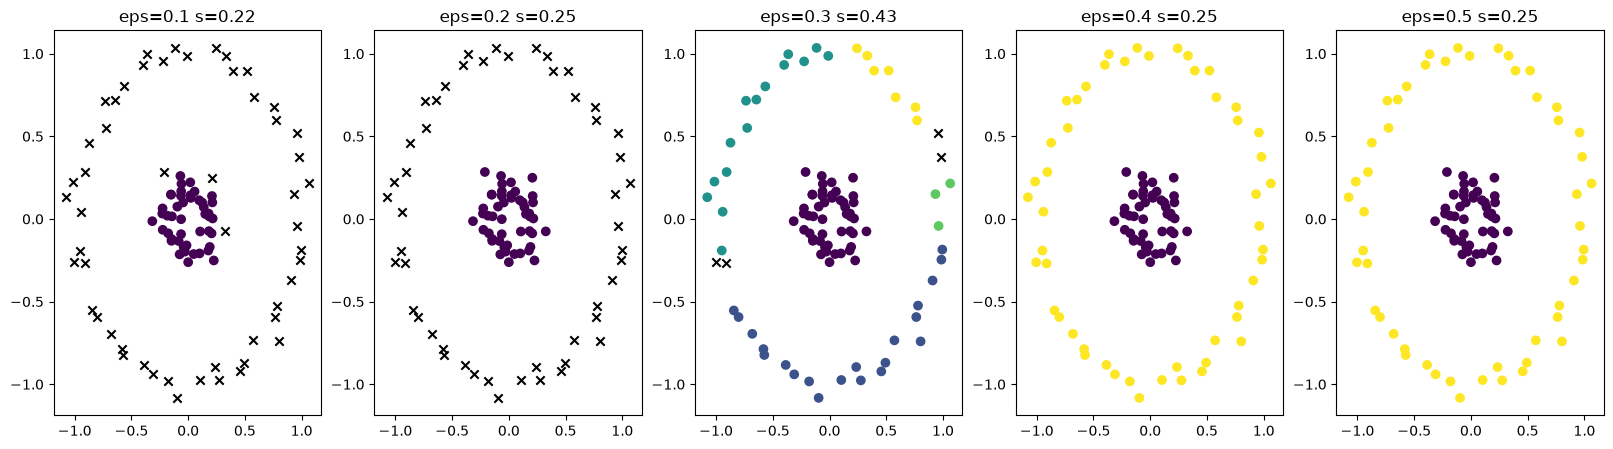

In [12]:
fig = plt.figure(figsize=(20, 5))
for idx, eps in enumerate([0.1, 0.2, 0.3, 0.4, 0.5]):
    model = DBSCAN(min_samples=5, eps=eps)
    model.fit(df)
    plt.subplot(1, 5, idx + 1)
    noise = df[model.labels_ == -1]
    plt.scatter(noise['feature_0'], noise['feature_1'], c='black', marker='x')
    not_noise = df[model.labels_ != -1]
    plt.scatter(not_noise['feature_0'], not_noise['feature_1'], c=model.labels_[model.labels_ != -1])
    plt.title(f'eps={eps} s={silhouette_score(df, model.labels_):.2f}')

Biramo parametre min\_samples=5 i eps=0.4 ili 0.5 da bismo dobili 2 klastera.

In [13]:
from sklearn.cluster import AgglomerativeClustering

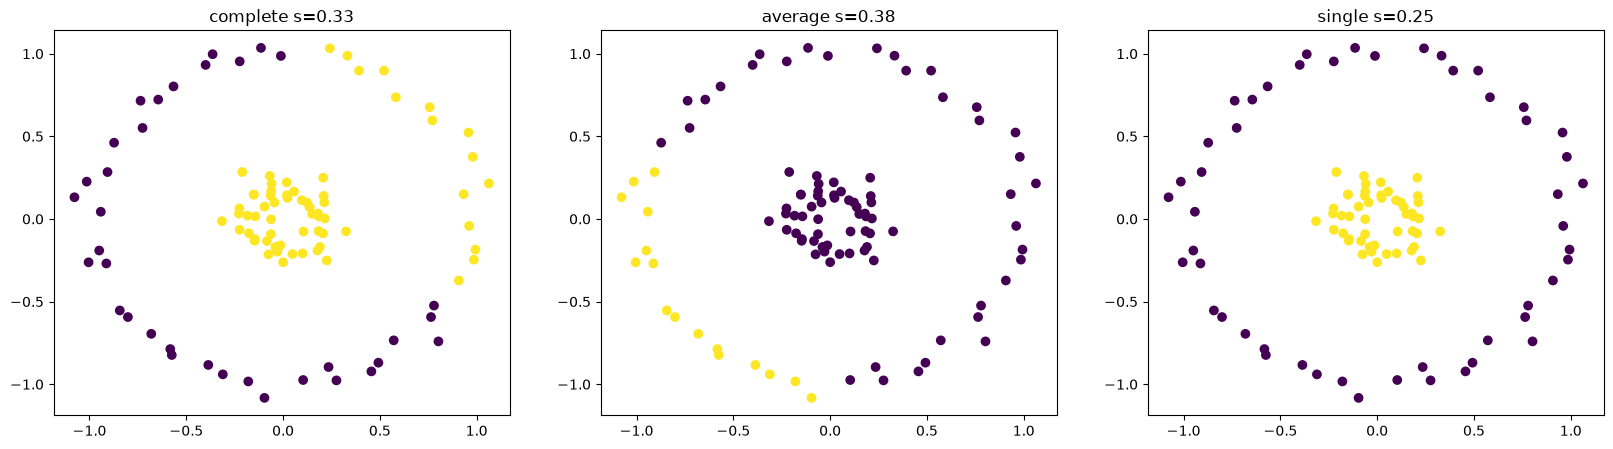

In [14]:
plt.figure(figsize=(20, 5))
for idx, linkage in enumerate(['complete', 'average', 'single']):
    model = AgglomerativeClustering(n_clusters=2, linkage=linkage)
    model.fit(df)
    plt.subplot(1, 3, idx + 1)
    plt.scatter(df['feature_0'], df['feature_1'], c=model.labels_)
    plt.title(f'{linkage} s={silhouette_score(df, model.labels_):.2f}')

Silueta nije dobra metrika za ovakav skup podataka zbog oblika klastera, pa vizuelno najbolje klasterovanje ima najmanju vrednost siluete.

Rezultati su očekivani - DBSCAN i single linkage pronalaze stvarne klastere, a complete i average ne.